In [2]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder
from sklearn.metrics import precision_score
import yfinance as yf

In [4]:
# Загрузка данных с Yahoo Finance
ticker = 'GOOGL'
data = yf.download(ticker, start='2015-01-01', end='2025-10-01')

# Используем только цену закрытия для предсказания
close_prices = data['Close'].values

[*********************100%***********************]  1 of 1 completed


In [5]:
# Нормализуем данные
def normalize(data: np.ndarray) -> np.ndarray:
    return (data - np.min(data)) / (np.max(data) - np.min(data))

#функция восстановления оригинальных данных с типизации аргументов и аннотацией выходного значения
def denormalize(normalized_data: np.ndarray, original_data: np.ndarray) -> np.ndarray:
    return normalized_data * (np.max(original_data) - np.min(original_data)) + np.min(original_data)

normalized_data = normalize(close_prices)

In [6]:
normalized_data.shape

(2702, 1)

In [7]:
# Определим функцию для подготовки данных (создание окна из N предыдущих значений)
def create_dataset(data: np.ndarray, window_size: int) -> tuple[np.ndarray]:
    """
    Создаём датасет, в котором признаками для целевой цены являются предыдущие <window_size> дней
    """
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X).reshape(-1, window_size), np.array(y)

In [18]:
create_dataset(normalized_data[:12], 10)

(array([[0.00701354, 0.00483544, 0.00206802, 0.00174637, 0.0021263 ,
         0.00079009, 0.        , 0.00102321, 0.00191474, 0.0015003 ],
        [0.00483544, 0.00206802, 0.00174637, 0.0021263 , 0.00079009,
         0.        , 0.00102321, 0.00191474, 0.0015003 , 0.00289263]]),
 array([[0.00289263],
        [0.00278037]]))

In [8]:
# Зададим окно
window_size = 10 # дней
X, y = create_dataset(normalized_data, window_size)

In [10]:
print(X.shape)
print(y.shape)

(2692, 10)
(2692, 1)


In [19]:
# Разделим данные на тренировочные и тестовые
train_size = int(len(X) * 0.8)
X_train, y_train = X[:train_size], y[:train_size]
X_test, y_test = X[train_size:], y[train_size:]

In [20]:
# Простейший вариант расчета MSE
def mse_loss(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    error = y_true - y_pred
    error_squared = error ** 2
    mean_squared_error = error_squared.mean()
    return mean_squared_error

Epoch 100/1000, Loss: 0.00011809298906861255
Epoch 200/1000, Loss: 9.642288227161039e-05
Epoch 300/1000, Loss: 9.509445055522397e-05
Epoch 400/1000, Loss: 9.4125280267219e-05
Epoch 500/1000, Loss: 9.340426494732569e-05
Epoch 600/1000, Loss: 9.281787746461406e-05
Epoch 700/1000, Loss: 9.233129051443405e-05
Epoch 800/1000, Loss: 9.191313803511819e-05
Epoch 900/1000, Loss: 9.155023054820767e-05
Epoch 1000/1000, Loss: 9.121569697428186e-05


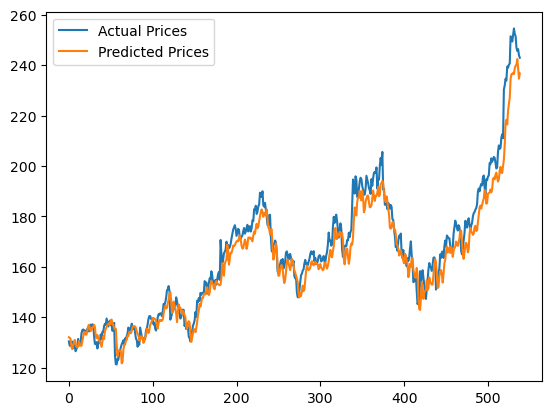

In [21]:
# Определение нейронной сети с применением Leaky ReLU
class SimpleNN:
    def __init__(self, input_size: int, hidden_size: int, output_size: int) -> None:
        # Инициализируем веса
        self.W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2. / input_size)
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2. / hidden_size)
        self.b2 = np.zeros((1, output_size))

    # Используем Leaky ReLU, чтобы избежать 0
    def leaky_relu(self, x: np.ndarray, alpha: float=0.01) -> np.ndarray:
        return np.where(x > 0, x, alpha * x)

    def leaky_relu_derivative(self, x: np.ndarray, alpha: float=0.01) -> np.ndarray:
        return np.where(x > 0, 1, alpha)

    def forward(self, X: np.ndarray) -> np.ndarray:
        # Прямое распространение
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = self.leaky_relu(self.z1)
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        output = self.z2  # Линейный выход для регрессии
        return output

    def backward(self, X: np.ndarray, y: np.ndarray, output: np.ndarray, learning_rate: float) -> None:
        # Обратное распространение
        output_error = output - y.reshape(-1, 1)
        dW2 = np.dot(self.a1.T, output_error)
        db2 = np.sum(output_error, axis=0, keepdims=True)

        a1_error = np.dot(output_error, self.W2.T) * self.leaky_relu_derivative(self.a1)
        dW1 = np.dot(X.T, a1_error)
        db1 = np.sum(a1_error, axis=0, keepdims=True)

        # Обновляем веса
        self.W2 -= learning_rate * dW2
        self.b2 -= learning_rate * db2
        self.W1 -= learning_rate * dW1
        self.b1 -= learning_rate * db1

    def train(self, X: np.ndarray, y: np.ndarray, epochs: int, learning_rate: float) -> None:
        for epoch in range(epochs):
            output = self.forward(X)
            self.backward(X, y, output, learning_rate)

            if (epoch + 1) % 100 == 0:
                loss = mse_loss(output, y.reshape(-1, 1))
                print(f'Epoch {epoch + 1}/{epochs}, Loss: {loss}')

# Параметры нейронной сети
input_size = window_size
hidden_size = 10
output_size = 1
learning_rate = 0.0001
epochs = 1000

# Создаем и обучаем модель
nn = SimpleNN(input_size, hidden_size, output_size)
nn.train(X_train, y_train, epochs, learning_rate)

# Предсказание на тестовых данных
predictions = nn.forward(X_test)

# Деинормализуем предсказанные и фактические данные
predicted_prices = denormalize(predictions, close_prices)
actual_prices = denormalize(y_test, close_prices)

# Визуализация результатов
plt.plot(actual_prices, label='Actual Prices')
plt.plot(predicted_prices, label='Predicted Prices')
plt.legend()
plt.show()


Почему np.sqrt(2. / input_size)?
Этот множитель — "магическое число" из исследования Kaiming He (Хе Каймин).

Для ReLU-активации: Функция ReLU(x) = max(0, x) "убивает" половину сигнала (все отрицательные значения). Это уменьшает дисперсию выходного сигнала вдвое по сравнению с линейной функцией.

Компенсация: Чтобы исправить это "прореживание", нужно увеличить дисперсию весов в 2 раза. В формуле для дисперсии это означает умножить на 2.

Масштабирование на размер слоя: Дисперсия суммы n случайных величин (нейронов предыдущего слоя) растет пропорционально n. Чтобы нормализовать это, мы делим на n (в вашем случае input_size для первого слоя).

Итог: Объединяем пункты 2 и 3. Нужно умножить дисперсию на 2 и разделить на n. Стандартное отклонение (которое мы задаем через randn()) — это квадратный корень из дисперсии. Поэтому и получается коэффициент: √(2 / n).